In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from config.settings import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from scipy import stats

from google.oauth2 import service_account
from google.cloud import bigquery

creds = service_account.Credentials.from_service_account_file(KEY_PATH)

bq_client = bigquery.Client(
    credentials=creds,
    project=GCP_PROJECT
)

print("Ready for DiD analysis")

/opt/anaconda3/envs/envhealth/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Ready for DiD analysis


In [2]:
laqn = pd.read_parquet(f"{DATA_DIR}/laqn_clean.parquet")

print(laqn.shape)
print(laqn.columns)
laqn.head()

(4260245, 8)
Index(['MeasurementDateGMT', 'no2', 'site_code', 'borough', 'latitude',
       'longitude', 'year', 'month'],
      dtype='object')


,MeasurementDateGMT,no2,site_code,borough,latitude,longitude,year,month
104894,2018-01-01 02:00:00,10.8,BG1,Barking and Dagenham,51.563752,0.177891,2018,1
104895,2018-01-01 03:00:00,10.3,BG1,Barking and Dagenham,51.563752,0.177891,2018,1
104896,2018-01-01 04:00:00,8.2,BG1,Barking and Dagenham,51.563752,0.177891,2018,1
104897,2018-01-01 05:00:00,8.2,BG1,Barking and Dagenham,51.563752,0.177891,2018,1
104898,2018-01-01 06:00:00,10.3,BG1,Barking and Dagenham,51.563752,0.177891,2018,1


In [3]:
#Prepare monthly borough panel
laqn["MeasurementDateGMT"] = pd.to_datetime(laqn["MeasurementDateGMT"])

laqn["year_month"] = laqn["MeasurementDateGMT"].dt.to_period("M").astype(str)

monthly_no2 = (
    laqn
    .groupby(["borough", "year_month"])
    .agg(
        no2_mean=("no2", "mean"),
        no2_count=("no2", "count"),
        site_count=("site_code", "nunique")
    )
    .reset_index()
)

monthly_no2.head()

,borough,year_month,no2_mean,no2_count,site_count
0,Barking and Dagenham,2018-01,27.416492,1431,2
1,Barking and Dagenham,2018-02,30.394190,1308,2
2,Barking and Dagenham,2018-03,29.696388,1218,2
3,Barking and Dagenham,2018-04,23.099738,1144,2
4,Barking and Dagenham,2018-05,24.932550,1149,2


In [4]:
print(monthly_no2.shape)
print(monthly_no2["year_month"].min(), monthly_no2["year_month"].max())
monthly_no2.groupby("year_month")["borough"].nunique().head()

(1910, 5)
2018-01 2023-12


year_month
2018-01    28
2018-02    28
2018-03    28
2018-04    28
2018-05    28
Name: borough, dtype: int64

In [5]:
monthly_no2["date"] = pd.to_datetime(monthly_no2["year_month"] + "-01")

monthly_no2.head()

,borough,year_month,no2_mean,no2_count,site_count,date
0,Barking and Dagenham,2018-01,27.416492,1431,2,2018-01-01
1,Barking and Dagenham,2018-02,30.394190,1308,2,2018-02-01
2,Barking and Dagenham,2018-03,29.696388,1218,2,2018-03-01
3,Barking and Dagenham,2018-04,23.099738,1144,2,2018-04-01
4,Barking and Dagenham,2018-05,24.932550,1149,2,2018-05-01


In [6]:
monthly_no2["borough"] = monthly_no2["borough"].replace({
    "Kingston": "Kingston upon Thames",
    "Richmond": "Richmond upon Thames"
})

In [7]:
monthly_no2 = monthly_no2.rename(columns={"borough": "borough_name"})

In [8]:
#Define treatment group
#use an inner-London treated group.
treated_boroughs = [
    "Camden",
    "City of London",
    "Hackney",
    "Hammersmith and Fulham",
    "Haringey",
    "Islington",
    "Kensington and Chelsea",
    "Lambeth",
    "Lewisham",
    "Newham",
    "Southwark",
    "Tower Hamlets",
    "Wandsworth",
    "Westminster"
]

In [9]:
monthly_no2["treated"] = monthly_no2["borough_name"].isin(treated_boroughs).astype(int)

monthly_no2[["borough_name", "treated"]].drop_duplicates().sort_values("borough_name")

,borough_name,treated
0,Barking and Dagenham,0
68,Bexley,0
136,Brent,0
204,Bromley,0
249,Camden,1
313,City of London,1
376,Croydon,0
444,Ealing,0
512,Enfield,0
580,Greenwich,0


In [ ]:
#Boroughs substantially inside or overlapping the 2021 ULEZ expansion area were treated as the treatment group; outer boroughs were used as the comparison group. This borough-level approximation is a limitation because the ULEZ boundary does not perfectly match borough boundaries.

In [10]:
#Define post-policy period
#post = November 2021 onward
monthly_no2["post"] = (monthly_no2["date"] >= "2021-11-01").astype(int)

# Exclude October 2021 as transition month
monthly_no2 = monthly_no2[monthly_no2["date"] != "2021-10-01"].copy()

monthly_no2["did"] = monthly_no2["treated"] * monthly_no2["post"]

monthly_no2[["borough_name", "date", "treated", "post", "did", "no2_mean"]].head()

,borough_name,date,treated,post,did,no2_mean
0,Barking and Dagenham,2018-01-01,0,0,0,27.416492
1,Barking and Dagenham,2018-02-01,0,0,0,30.394190
2,Barking and Dagenham,2018-03-01,0,0,0,29.696388
3,Barking and Dagenham,2018-04-01,0,0,0,23.099738
4,Barking and Dagenham,2018-05-01,0,0,0,24.932550


In [11]:
#Restrict analysis period
#2018-01 to 2023-12
monthly_no2 = monthly_no2[
    (monthly_no2["date"] >= "2018-01-01") &
    (monthly_no2["date"] <= "2023-12-31")
].copy()

print(monthly_no2["date"].min(), monthly_no2["date"].max())

2018-01-01 00:00:00 2023-12-01 00:00:00


In [12]:
monthly_no2.groupby("treated")["borough_name"].nunique()

treated
0    16
1    13
Name: borough_name, dtype: int64

In [13]:
monthly_no2.groupby(["treated", "post"]).agg(
    boroughs=("borough_name", "nunique"),
    observations=("no2_mean", "count"),
    mean_no2=("no2_mean", "mean")
)

boroughs  observations   mean_no2
treated post                                   
0       0           16           622  32.230916
        1           16           398  25.350410
1       0           13           533  37.875475
        1           13           329  27.624538

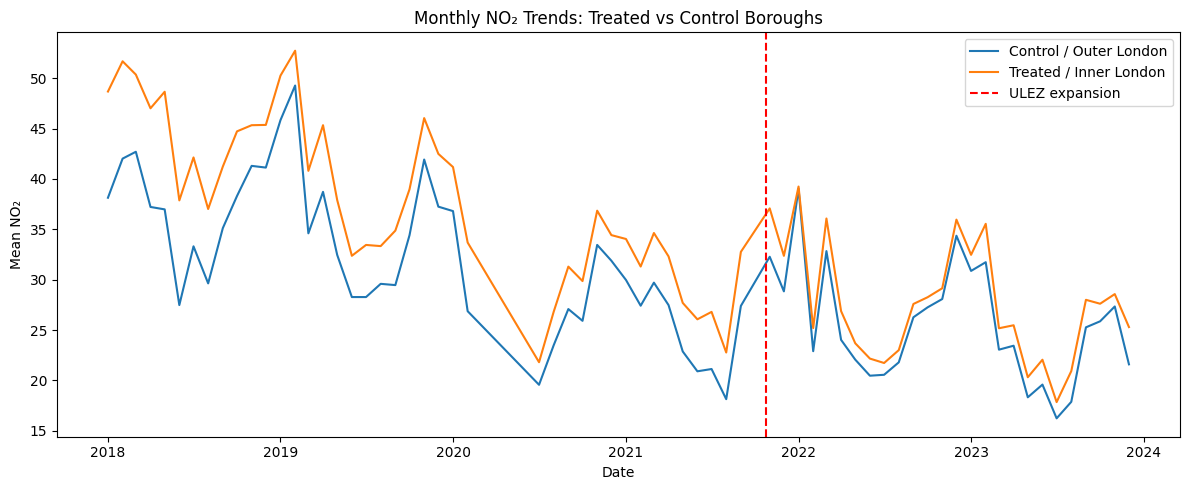

In [14]:
#Parallel trends plot
trend = (
    monthly_no2
    .groupby(["date", "treated"])["no2_mean"]
    .mean()
    .reset_index()
)

trend["group"] = trend["treated"].map({
    1: "Treated / Inner London",
    0: "Control / Outer London"
})

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=trend,
    x="date",
    y="no2_mean",
    hue="group"
)

plt.axvline(pd.to_datetime("2021-10-25"), color="red", linestyle="--", label="ULEZ expansion")
plt.title("Monthly NO₂ Trends: Treated vs Control Boroughs")
plt.xlabel("Date")
plt.ylabel("Mean NO₂")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_did_parallel_trends.png", dpi=150)
plt.show()

In [15]:
#Run simple DiD regression
did_model = smf.ols(
    "no2_mean ~ treated + post + did",
    data=monthly_no2
).fit(cov_type="HC3")

print(did_model.summary())

                            OLS Regression Results                            
Dep. Variable:               no2_mean   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     123.6
Date:                Mon, 18 May 2026   Prob (F-statistic):           4.42e-73
Time:                        10:52:26   Log-Likelihood:                -7116.2
No. Observations:                1882   AIC:                         1.424e+04
Df Residuals:                    1878   BIC:                         1.426e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     32.2309      0.425     75.878      0.0

In [16]:
#Run stronger fixed-effects DiD model
monthly_no2["borough_fe"] = monthly_no2["borough_name"].astype("category")
monthly_no2["date_fe"] = monthly_no2["date"].astype("category")

fe_model = smf.ols(
    "no2_mean ~ did + C(borough_name) + C(date)",
    data=monthly_no2
).fit(
    cov_type="cluster",
    cov_kwds={"groups": monthly_no2["borough_name"]}
)

print(fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:               no2_mean   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     237.2
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.01e-26
Time:                        10:53:18   Log-Likelihood:                -5314.6
No. Observations:                1882   AIC:                         1.082e+04
Df Residuals:                    1786   BIC:                         1.135e+04
Df Model:                          95                                         
Covariance Type:              cluster                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

/opt/anaconda3/envs/envhealth/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 95, but rank is 28
  warnings.warn('covariance of constraints does not have full '


In [17]:
did_coef = fe_model.params["did"]
did_p = fe_model.pvalues["did"]
did_ci = fe_model.conf_int().loc["did"]

print(f"DiD coefficient: {did_coef:.3f}")
print(f"95% CI: [{did_ci[0]:.3f}, {did_ci[1]:.3f}]")
print(f"p-value: {did_p:.4f}")

DiD coefficient: -3.202
95% CI: [-6.010, -0.393]
p-value: 0.0255


In [18]:
monthly_no2.groupby("treated")["borough_name"].nunique()
#conclusion:
#The DiD panel included 29 boroughs with usable monthly NO₂ observations: 13 treated boroughs and 16 control boroughs. Four boroughs were excluded because consistent LAQN monitoring data was unavailable.

treated
0    16
1    13
Name: borough_name, dtype: int64

In [19]:
print(f"DiD coefficient: {did_coef:.3f}")
#Inner/treated boroughs saw NO₂ fall by about 3.2 µg/m³ more than outer/control boroughs after the ULEZ expansion.
print(f"95% CI: [{did_ci[0]:.3f}, {did_ci[1]:.3f}]")
#The estimated reduction is uncertain, but the plausible range is approximately 0.39 to 6.01 µg/m³ lower NO₂ in treated boroughs relative to controls.
print(f"p-value: {did_p:.4f}")
#There is evidence that treated boroughs experienced a statistically significant relative reduction in NO₂ after the October 2021 ULEZ expansion.

DiD coefficient: -3.202
95% CI: [-6.010, -0.393]
p-value: 0.0255


In [21]:
print("Final interpretation")
print("The fixed-effects DiD model estimated a treatment effect of -3.20 µg/m³, with a 95% confidence interval from -6.01 to -0.39 and p = 0.026. This suggests that boroughs classified as treated experienced a statistically significant relative reduction in NO₂ after the October 2021 ULEZ expansion compared with control boroughs. However, the result should be interpreted cautiously because treatment status is approximated at borough level, while the actual ULEZ boundary follows the North and South Circular roads and does not align perfectly with borough boundaries.")

Final interpretation
The fixed-effects DiD model estimated a treatment effect of -3.20 µg/m³, with a 95% confidence interval from -6.01 to -0.39 and p = 0.026. This suggests that boroughs classified as treated experienced a statistically significant relative reduction in NO₂ after the October 2021 ULEZ expansion compared with control boroughs. However, the result should be interpreted cautiously because treatment status is approximated at borough level, while the actual ULEZ boundary follows the North and South Circular roads and does not align perfectly with borough boundaries.


In [22]:
did_summary = pd.DataFrame({
    "metric": [
        "DiD coefficient",
        "95% CI lower",
        "95% CI upper",
        "p-value"
    ],
    "value": [
        did_coef,
        did_ci[0],
        did_ci[1],
        did_p
    ]
})

did_summary

,metric,value
0,DiD coefficient,-3.201686
1,95% CI lower,-6.010108
2,95% CI upper,-0.393264
3,p-value,0.025456


In [23]:
did_summary.to_parquet(f"{DATA_DIR}/did_summary.parquet")
monthly_no2.to_parquet(f"{DATA_DIR}/did_monthly_panel.parquet")

In [24]:
BQ_TABLE_DID = f"{GCP_PROJECT}.{BQ_DATASET}.did_results"

In [25]:
job = bq_client.load_table_from_dataframe(
    did_summary,
    BQ_TABLE_DID,
    job_config=bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE"
    )
)

job.result()

print(f"Loaded DiD summary to BigQuery: {BQ_TABLE_DID}")

Loaded DiD summary to BigQuery: env-health-london-2026.env_health.did_results


In [26]:
BQ_TABLE_DID_PANEL = f"{GCP_PROJECT}.{BQ_DATASET}.did_monthly_panel"

job = bq_client.load_table_from_dataframe(
    monthly_no2,
    BQ_TABLE_DID_PANEL,
    job_config=bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE"
    )
)

job.result()

print(f"Loaded DiD panel to BigQuery: {BQ_TABLE_DID_PANEL}")

/opt/anaconda3/envs/envhealth/lib/python3.10/site-packages/google/cloud/bigquery/_pandas_helpers.py:570: UserWarning: Pyarrow could not determine the type of columns: borough_fe, date_fe.
  warnings.warn(


Loaded DiD panel to BigQuery: env-health-london-2026.env_health.did_monthly_panel


In [27]:
bq_client.query(f"SELECT * FROM `{BQ_TABLE_DID}`").to_dataframe()

,metric,value
0,DiD coefficient,-3.201686
1,95% CI lower,-6.010108
2,95% CI upper,-0.393264
3,p-value,0.025456


In [28]:
#Create final DiD report-card output
did_report_card = pd.DataFrame({
    "Item": [
        "Policy case study",
        "Treatment definition",
        "Control definition",
        "Policy date",
        "Model",
        "Estimated DiD effect",
        "95% confidence interval",
        "p-value",
        "Interpretation",
        "Main limitation"
    ],
    "Result": [
        "October 2021 ULEZ expansion",
        "Inner / treated boroughs approximating the 2021 ULEZ expansion area",
        "Outer London boroughs with usable LAQN monitoring data",
        "25 October 2021; November 2021 treated as first full post-policy month",
        "Two-way fixed effects OLS with borough and month fixed effects; clustered standard errors by borough",
        f"{did_coef:.3f} µg/m³",
        f"[{did_ci[0]:.3f}, {did_ci[1]:.3f}]",
        f"{did_p:.4f}",
        "Treated boroughs experienced an estimated relative NO₂ reduction compared with control boroughs after the ULEZ expansion.",
        "Treatment status is approximated at borough level, while the real ULEZ boundary does not perfectly match borough boundaries."
    ]
})

did_report_card

,Item,Result
0,Policy case study,October 2021 ULEZ expansion
1,Treatment definition,Inner / treated boroughs approximating the 202...
2,Control definition,Outer London boroughs with usable LAQN monitor...
3,Policy date,25 October 2021; November 2021 treated as firs...
4,Model,Two-way fixed effects OLS with borough and mon...
5,Estimated DiD effect,-3.202 µg/m³
6,95% confidence interval,"[-6.010, -0.393]"
7,p-value,0.0255
8,Interpretation,Treated boroughs experienced an estimated rela...
9,Main limitation,Treatment status is approximated at borough le...


In [29]:
did_report_card.to_csv(f"{DATA_DIR}/did_report_card.csv", index=False)
did_report_card.to_parquet(f"{DATA_DIR}/did_report_card.parquet")

print("Saved DiD report card")

Saved DiD report card


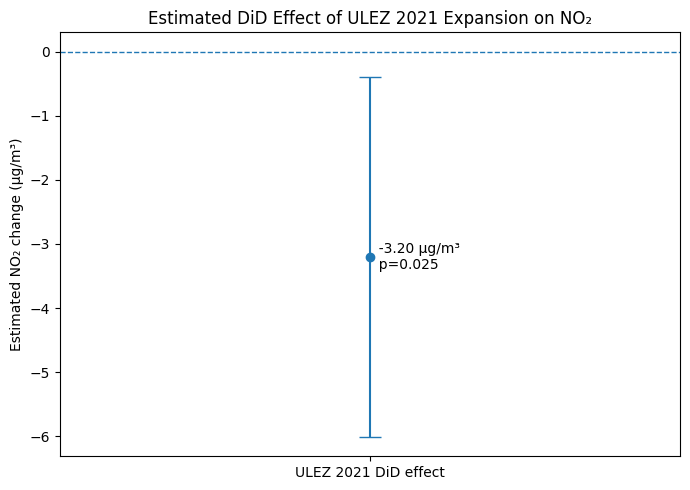

In [30]:
#Create a final DiD coefficient chart
plt.figure(figsize=(7, 5))

plt.errorbar(
    x=[0],
    y=[did_coef],
    yerr=[[did_coef - did_ci[0]], [did_ci[1] - did_coef]],
    fmt="o",
    capsize=8
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xticks([0], ["ULEZ 2021 DiD effect"])
plt.ylabel("Estimated NO₂ change (µg/m³)")
plt.title("Estimated DiD Effect of ULEZ 2021 Expansion on NO₂")

plt.text(
    0,
    did_coef,
    f"  {did_coef:.2f} µg/m³\n  p={did_p:.3f}",
    va="center"
)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_did_effect_estimate.png", dpi=150)
plt.show()

In [ ]:
#The DiD effect estimate was -3.20 µg/m³, with a 95% confidence interval from -6.01 to -0.39 and p = 0.026. This suggests a statistically significant relative NO₂ reduction in treated boroughs after the October 2021 ULEZ expansion, compared with control boroughs.

In [31]:
#Create pre/post group summary chart
group_summary = (
    monthly_no2
    .groupby(["treated", "post"])["no2_mean"]
    .mean()
    .reset_index()
)

group_summary["group"] = group_summary["treated"].map({
    1: "Treated",
    0: "Control"
})

group_summary["period"] = group_summary["post"].map({
    1: "Post-ULEZ",
    0: "Pre-ULEZ"
})

group_summary

,treated,post,no2_mean,group,period
0,0,0,32.230916,Control,Pre-ULEZ
1,0,1,25.350410,Control,Post-ULEZ
2,1,0,37.875475,Treated,Pre-ULEZ
3,1,1,27.624538,Treated,Post-ULEZ


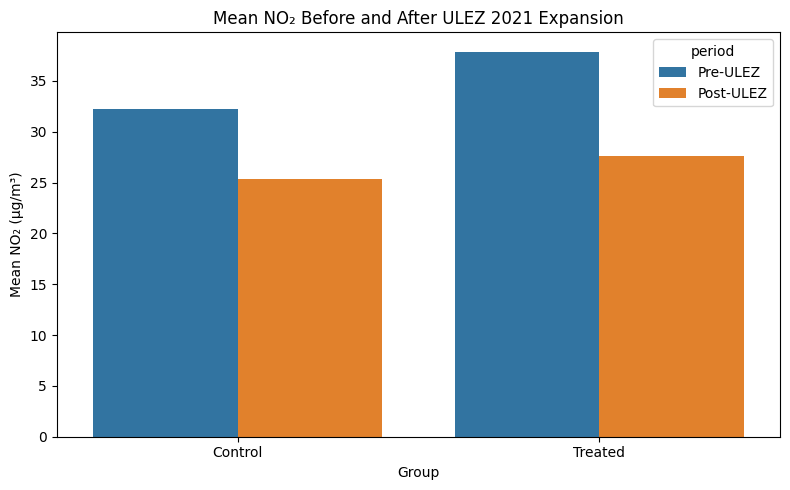

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=group_summary,
    x="group",
    y="no2_mean",
    hue="period"
)

plt.ylabel("Mean NO₂ (µg/m³)")
plt.xlabel("Group")
plt.title("Mean NO₂ Before and After ULEZ 2021 Expansion")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_did_pre_post_group_summary.png", dpi=150)
plt.show()

In [33]:
BQ_TABLE_DID_REPORT = f"{GCP_PROJECT}.{BQ_DATASET}.did_report_card"

job = bq_client.load_table_from_dataframe(
    did_report_card,
    BQ_TABLE_DID_REPORT,
    job_config=bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE"
    )
)

job.result()

print(f"Loaded DiD report card to BigQuery: {BQ_TABLE_DID_REPORT}")

Loaded DiD report card to BigQuery: env-health-london-2026.env_health.did_report_card


In [34]:
bq_client.query(f"SELECT * FROM `{BQ_TABLE_DID_REPORT}`").to_dataframe()

,Item,Result
0,Policy case study,October 2021 ULEZ expansion
1,Treatment definition,Inner / treated boroughs approximating the 202...
2,Control definition,Outer London boroughs with usable LAQN monitor...
3,Policy date,25 October 2021; November 2021 treated as firs...
4,Model,Two-way fixed effects OLS with borough and mon...
5,Estimated DiD effect,-3.202 µg/m³
6,95% confidence interval,"[-6.010, -0.393]"
7,p-value,0.0255
8,Interpretation,Treated boroughs experienced an estimated rela...
9,Main limitation,Treatment status is approximated at borough le...


In [35]:
print("DiD Interpretation")
print("The fixed-effects DiD model estimated a treatment effect of approximately -3.20 µg/m³, with a 95% confidence interval from -6.01 to -0.39 and p = 0.026. This suggests that treated boroughs experienced a statistically significant relative reduction in NO₂ after the October 2021 ULEZ expansion compared with control boroughs.")
print("This result should be interpreted cautiously. The ULEZ boundary follows the North and South Circular roads, whereas this project uses borough-level treatment assignment. Some boroughs are only partially covered by the expansion zone, and LAQN monitoring coverage is uneven across London. Therefore, the DiD analysis is best understood as a policy case study demonstrating the platform’s evaluation capability rather than a definitive causal evaluation.")

DiD Interpretation
The fixed-effects DiD model estimated a treatment effect of approximately -3.20 µg/m³, with a 95% confidence interval from -6.01 to -0.39 and p = 0.026. This suggests that treated boroughs experienced a statistically significant relative reduction in NO₂ after the October 2021 ULEZ expansion compared with control boroughs.
This result should be interpreted cautiously. The ULEZ boundary follows the North and South Circular roads, whereas this project uses borough-level treatment assignment. Some boroughs are only partially covered by the expansion zone, and LAQN monitoring coverage is uneven across London. Therefore, the DiD analysis is best understood as a policy case study demonstrating the platform’s evaluation capability rather than a definitive causal evaluation.
